# Supply Chain Performance Analysis
### Data Preprocessing,Exploratory Data Analysis (EDA) & Feature Engineering

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(
    r"D:\Documents\Project\DataFiles\DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

In [5]:

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
df.isnull().sum().sort_values(ascending=False)

Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Type                                  0
Order Profit Per Order                0
Order Item Cardprod Id                0
Order Item Discount                   0
Order Item Discount Rate              0
Order Item Id                         0
Order Item Product Price              0
Order Item Profit Ratio               0
Order Item Quantity                   0
Sales                                 0
Order Item Total                      0
Order Region                          0
order date (DateOrders)               0
Order State                           0
Order Status                          0
Product Card Id                       0
Product Category Id                   0
Product Image                         0
Product Name                          0
Product Price                         0
Product Status                        0


Columns such as Product Description and Order Zipcode contain a substantial number of missing values, making them unsuitable for analysis. These columns will be dropped

In [4]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [5]:
# Remove unnecessary columns

cols_to_drop = [
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Product Description",
    "Product Image",
    "Latitude",
    "Longitude"
]

df.drop(columns=cols_to_drop, inplace=True)

In [6]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State',
       'Customer Zipcode', 'Department Id', 'Department Name', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product Name', 'Product Price', 'Product Status',
       'shipping date (DateOrders)', 'Shipping Mode'],
      dtype='object')

In [7]:
cols_to_drop = [
    "Benefit per order",
    "Sales per customer",
    "Category Id",
    "Department Id",
    "Order Item Cardprod Id",
    "Order Item Id",
    "Customer Zipcode",
    "Order Zipcode"
]

df.drop(columns=cols_to_drop, inplace=True)

In [8]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Delivery Status', 'Late_delivery_risk', 'Category Name',
       'Customer City', 'Customer Country', 'Customer Id', 'Customer Segment',
       'Customer State', 'Department Name', 'Market', 'Order City',
       'Order Country', 'Order Customer Id', 'order date (DateOrders)',
       'Order Id', 'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Name',
       'Product Price', 'Product Status', 'shipping date (DateOrders)',
       'Shipping Mode'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Delivery Status                180519 non-null  object 
 4   Late_delivery_risk             180519 non-null  int64  
 5   Category Name                  180519 non-null  object 
 6   Customer City                  180519 non-null  object 
 7   Customer Country               180519 non-null  object 
 8   Customer Id                    180519 non-null  int64  
 9   Customer Segment               180519 non-null  object 
 10  Customer State                 180519 non-null  object 
 11  Department Name                180519 non-null  object 
 12  Market                        

In [10]:
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Delivery Status                180519 non-null  object        
 4   Late_delivery_risk             180519 non-null  int64         
 5   Category Name                  180519 non-null  object        
 6   Customer City                  180519 non-null  object        
 7   Customer Country               180519 non-null  object        
 8   Customer Id                    180519 non-null  int64         
 9   Customer Segment               180519 non-null  object        
 10  Customer State                 180519 non-null  object        
 11  

In [12]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset.

In [13]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Days for shipping (real),180519.0,3.497654,0.0,2.0,3.0,5.0,6.0,1.623722
Days for shipment (scheduled),180519.0,2.931847,0.0,2.0,4.0,4.0,4.0,1.374449
Late_delivery_risk,180519.0,0.548291,0.0,0.0,1.0,1.0,1.0,0.497664
Customer Id,180519.0,6691.379495,1.0,3258.5,6457.0,9779.0,20757.0,4162.918106
Order Customer Id,180519.0,6691.379495,1.0,3258.5,6457.0,9779.0,20757.0,4162.918106
order date (DateOrders),180519,2016-06-12 17:47:04.669868544,2015-01-01 00:00:00,2015-09-21 13:49:00,2016-06-11 13:06:00,2017-03-01 08:42:00,2018-01-31 23:38:00,NaN
Order Id,180519.0,36221.894903,1.0,18057.0,36140.0,54144.0,77204.0,21045.379569
Order Item Discount,180519.0,20.664741,0.0,5.4,14.0,29.99,500.0,21.800901
Order Item Discount Rate,180519.0,0.101668,0.0,0.04,0.1,0.16,0.25,0.070415
Order Item Product Price,180519.0,141.23255,9.99,50.0,59.990002,199.990005,1999.98999,139.732492


In [14]:
(df["Customer Id"] == df["Order Customer Id"]).all()

np.True_

In [15]:
(df["Product Price"] == df["Order Item Product Price"]).all()

np.True_

In [16]:
df["Product Status"].value_counts()

Product Status
0    180519
Name: count, dtype: int64

In [17]:
df.drop(columns=[
    "Order Customer Id",
    "Order Item Product Price",
    "Product Status"
], inplace=True)

In [19]:
df["Order Status"].value_counts()

Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

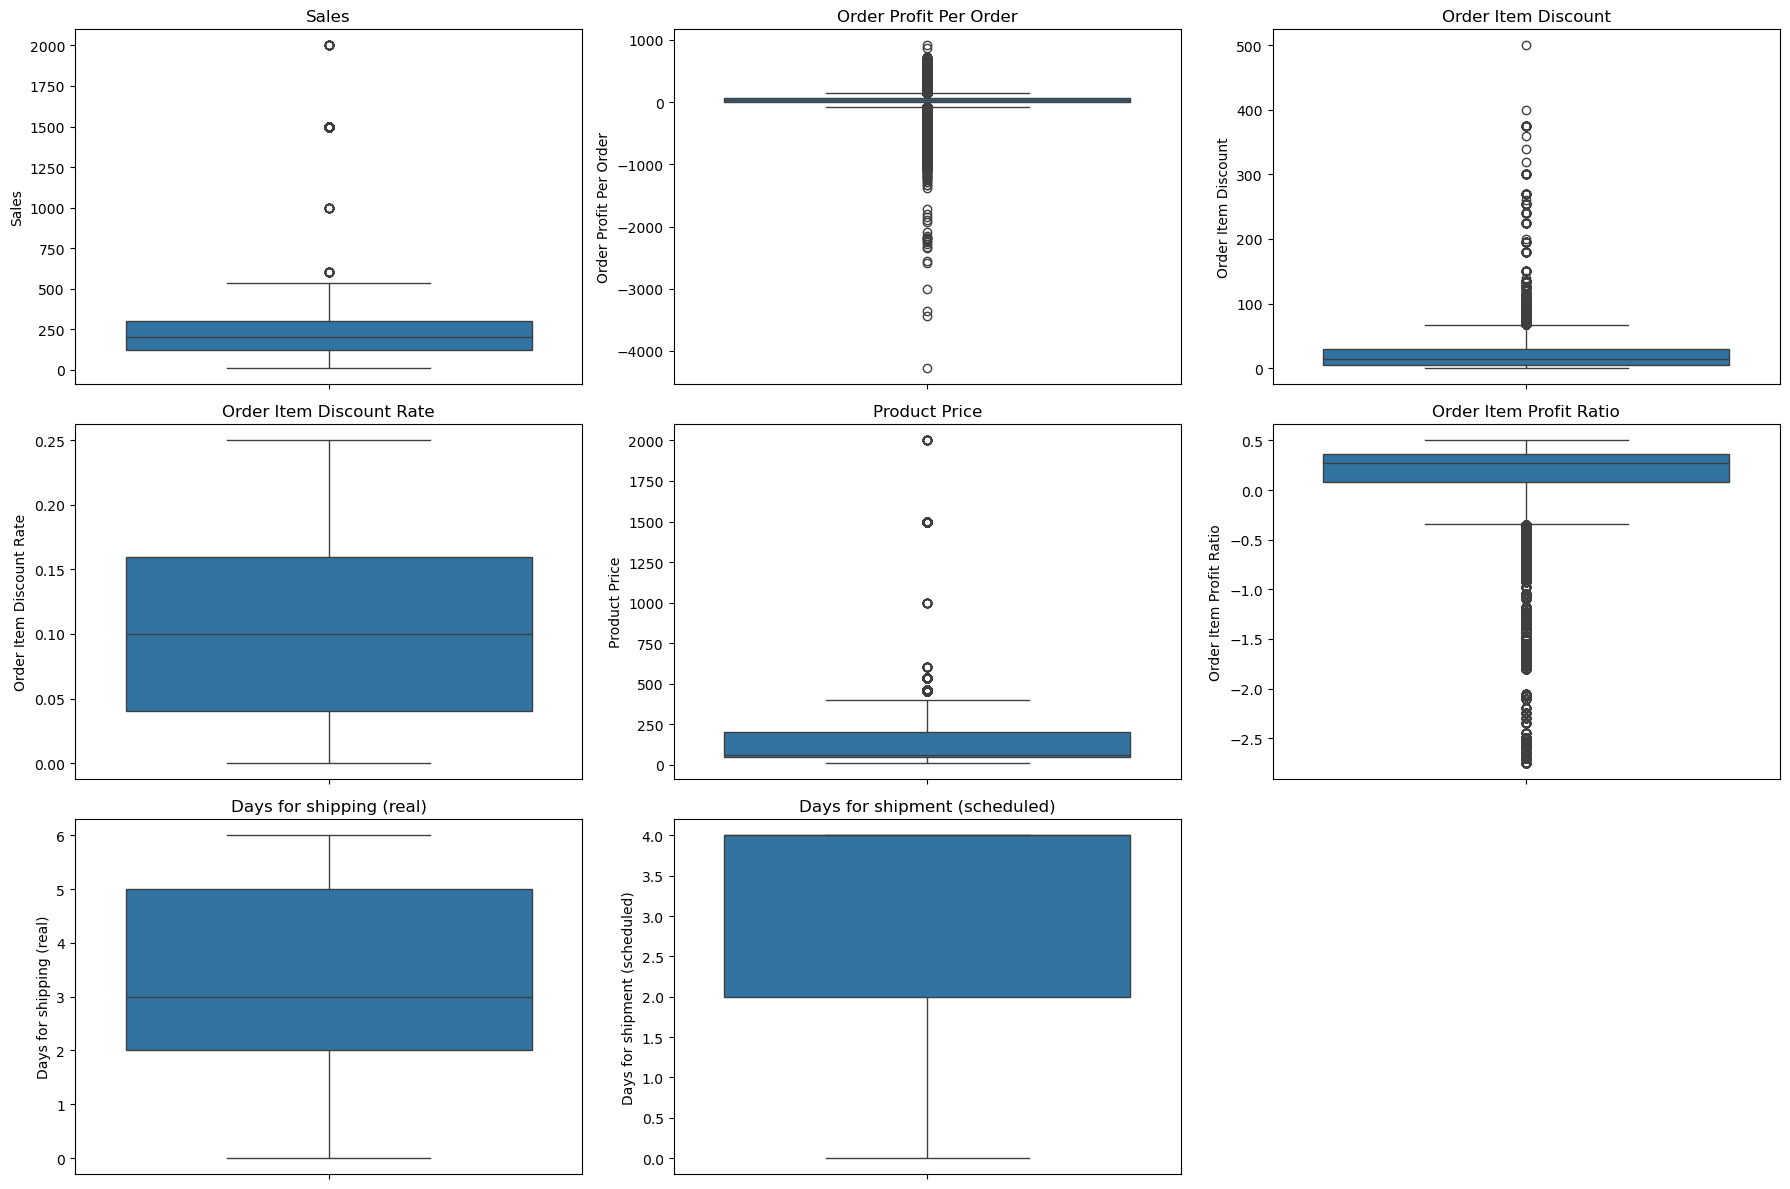

In [20]:
# Outlier Treatment
cols = [
    "Sales",
    "Order Profit Per Order",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Product Price",
    "Order Item Profit Ratio",
    "Days for shipping (real)",
    "Days for shipment (scheduled)"
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Outliers were identified in a few numerical variables. After investigation, they were retained as they represent genuine business scenarios such as premium products, bulk purchases, promotional discounts, and loss-making orders rather than data entry errors.

In [21]:
# Visualization-Friendly Outlier Capping
# Cap Sales at the 99th percentile
sales_cap = df["Sales"].quantile(0.99)
df["sales_capped"] = df["Sales"].clip(upper=sales_cap)

# Cap Product Price at the 99th percentile
price_cap = df["Product Price"].quantile(0.99)
df["product_price_capped"] = df["Product Price"].clip(upper=price_cap)

# Cap Order Profit Per Order at the 1st and 99th percentiles
profit_lower = df["Order Profit Per Order"].quantile(0.01)
profit_upper = df["Order Profit Per Order"].quantile(0.99)

df["order_profit_capped"] = df["Order Profit Per Order"].clip(
    lower=profit_lower,
    upper=profit_upper
)

# Feature Engineering

In [22]:
# 1. Delivery delay
df["Delay Days"] = (
    df["Days for shipping (real)"] -
    df["Days for shipment (scheduled)"]
)

# 2. Delivery category
df["Delay Category"] = pd.cut(
    df["Delay Days"],
    bins=[-100, 0, 2, 100],
    labels=["On Time/Early", "1-2 Days Late", "3+ Days Late"]
)

# 3. Profit margin (%)
df["Profit Margin (%)"] = (
    df["Order Profit Per Order"] / df["Sales"]
) * 100

# 4. Revenue at risk
df["Revenue at Risk"] = np.where(
    df["Late_delivery_risk"] == 1,
    df["Sales"],
    0
)

In [23]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Delivery Status', 'Late_delivery_risk', 'Category Name',
       'Customer City', 'Customer Country', 'Customer Id', 'Customer Segment',
       'Customer State', 'Department Name', 'Market', 'Order City',
       'Order Country', 'order date (DateOrders)', 'Order Id',
       'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order State', 'Order Status', 'Product Card Id', 'Product Category Id',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'sales_capped', 'product_price_capped',
       'order_profit_capped', 'Delay Days', 'Delay Category',
       'Profit Margin (%)', 'Revenue at Risk'],
      dtype='object')

In [24]:
# 5. Weekend flag
df["Weekend Flag"] = np.where(
    df["order date (DateOrders)"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)
# 6. Order processing time
df["Order Processing Time"] = (
    df["shipping date (DateOrders)"] -
    df["order date (DateOrders)"]
).dt.days

In [25]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Delivery Status', 'Late_delivery_risk', 'Category Name',
       'Customer City', 'Customer Country', 'Customer Id', 'Customer Segment',
       'Customer State', 'Department Name', 'Market', 'Order City',
       'Order Country', 'order date (DateOrders)', 'Order Id',
       'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order State', 'Order Status', 'Product Card Id', 'Product Category Id',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'sales_capped', 'product_price_capped',
       'order_profit_capped', 'Delay Days', 'Delay Category',
       'Profit Margin (%)', 'Revenue at Risk', 'Weekend Flag',
       'Order Processing Time'],
      dtype='object')

# Exploratory Data Analysis

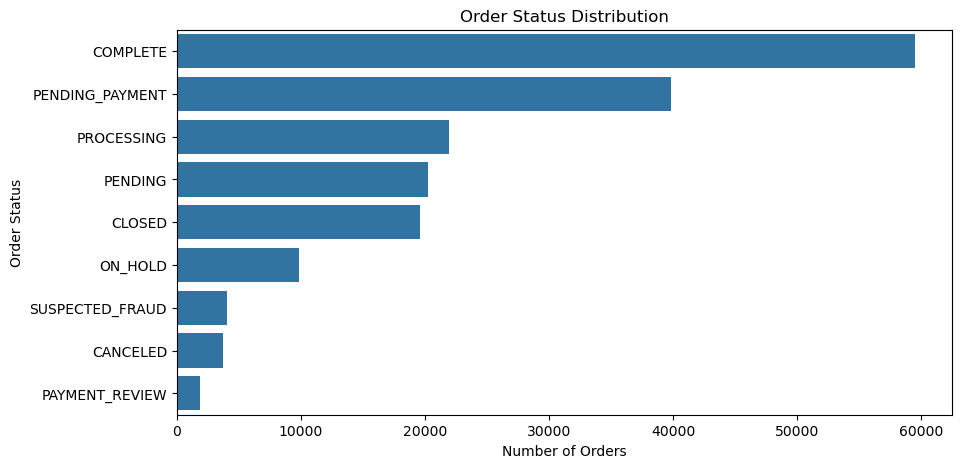

In [26]:
# Plot order status distribution
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="Order Status",
    order=df["Order Status"].value_counts().index
)

plt.title("Order Status Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Order Status")

plt.show()

### Key Insights

- Most orders are successfully completed.
- Pending payment and processing orders present opportunities to improve operational efficiency.
- Canceled and suspected fraud orders account for only a small share of total orders.

## Customer Segment Analysis
Analyze the distribution of orders across customer segments.

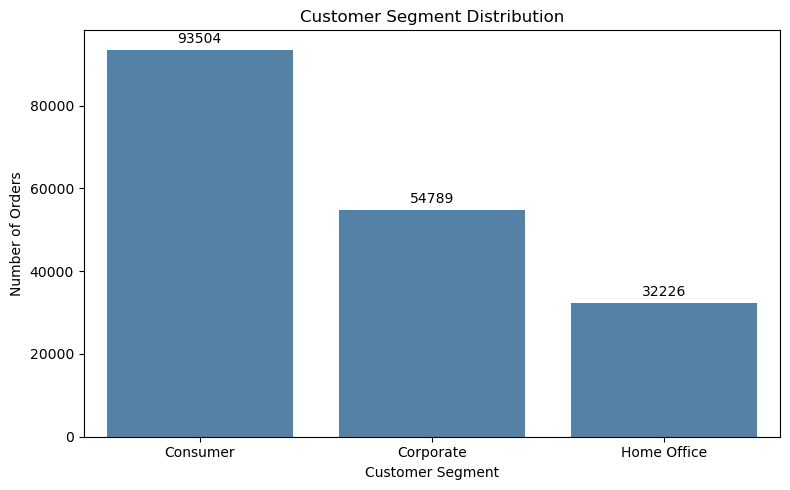

In [27]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Customer Segment",
    order=df["Customer Segment"].value_counts().index,
    color="steelblue"
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

### Key Insights

- Consumer customers place the highest number of orders.
- Corporate and Home Office segments contribute a smaller share of total orders.
- Customer demand is primarily driven by the Consumer segment.

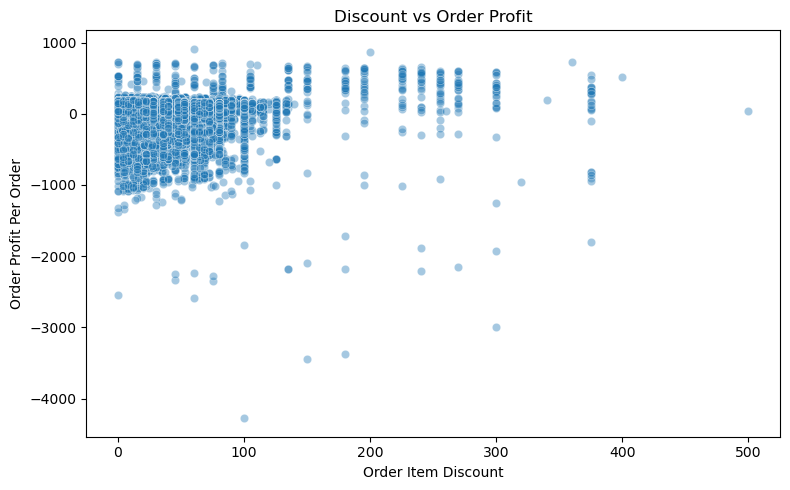

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Order Item Discount",
    y="Order Profit Per Order",
    alpha=0.4
)

plt.title("Discount vs Order Profit")
plt.xlabel("Order Item Discount")
plt.ylabel("Order Profit Per Order")

plt.tight_layout()
plt.show()

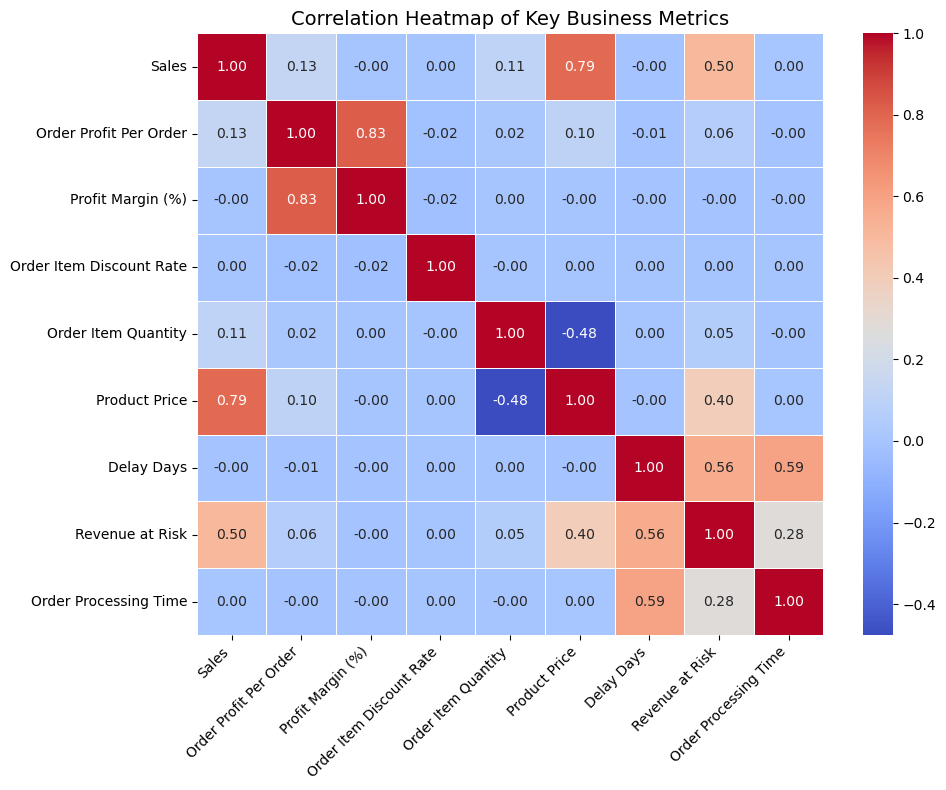

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns for correlation analysis
corr_columns = [
    'Sales',
    'Order Profit Per Order',
    'Profit Margin (%)',
    'Order Item Discount Rate',
    'Order Item Quantity',
    'Product Price',
    'Delay Days',
    'Revenue at Risk',
    'Order Processing Time'
]

# Compute correlation matrix
corr_matrix = df[corr_columns].corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Key Business Metrics', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Sales and profit exhibit a positive relationship, while higher discounts tend to reduce profit margins, highlighting the importance of balanced discount strategies

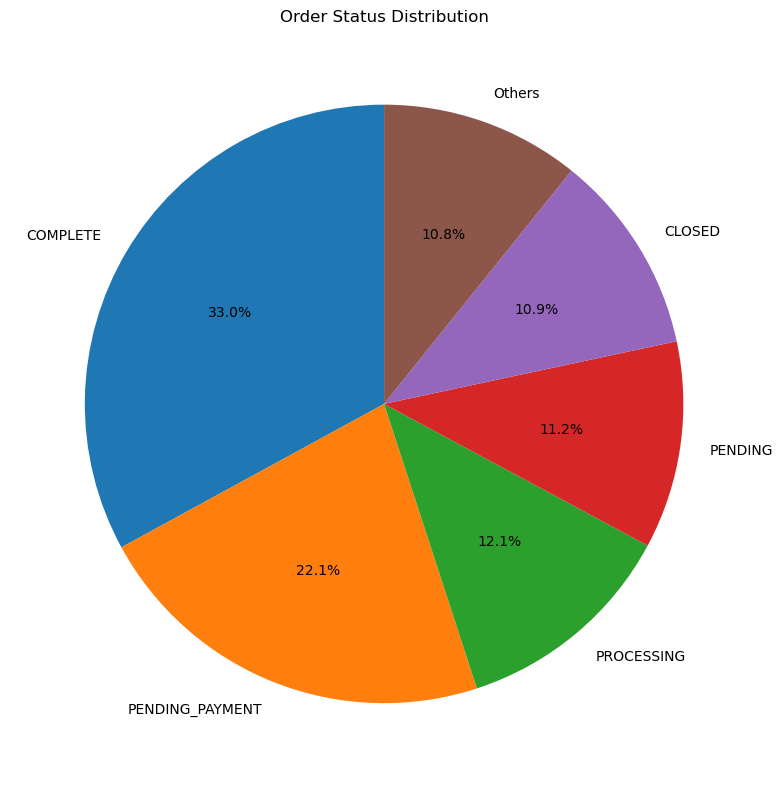

In [33]:
# Order Status Distribution
# What proportion of orders falls under each order status?

import matplotlib.pyplot as plt

order_status = df['Order Status'].value_counts()

# Keep top 5 statuses and group the rest
top5 = order_status.head(5)
others = order_status.iloc[5:].sum()

pie_data = top5.copy()
pie_data['Others'] = others

plt.figure(figsize=(8,8))

plt.pie(
    pie_data,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Order Status Distribution')

plt.tight_layout()
plt.show()

The majority of orders are successfully completed, indicating a generally efficient order fulfillment process. However, cancelled, pending payment, and fraud-related orders collectively represent a meaningful portion of transactions that can impact revenue realization

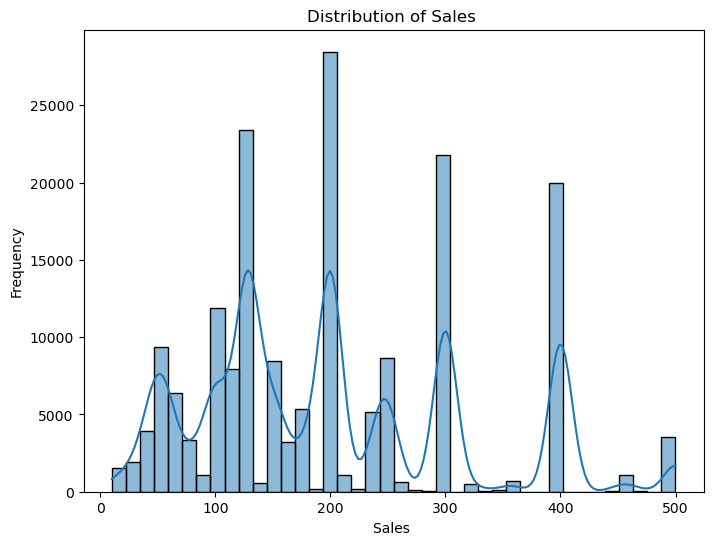

In [37]:
# Sales Distribution 
# How are customer order values distributed after outlier treatment?

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.histplot(
    df['sales_capped'],
    bins=40,
    kde=True
)

plt.title('Distribution of Sales ')
plt.xlabel('Sales ')
plt.ylabel('Frequency')

plt.show()

The distribution remains right skewed , indicating that most orders are of relatively low value while a smaller number contribute significantly higher sales

In [35]:
df.to_csv("supply_chain_cleaned.csv", index=False)


This analysis identified key business insights related to sales performance, customer behavior, profitability, delivery operations, and revenue optimization.

The engineered dataset was further utilized for SQL based business analysis and Power BI dashboard development to support strategic decision-making.